# Validation and plot generation notebook for PlatoSim3 paper (2022)

This notebook is used to generate all input plots shown in the PlatoSim3 paper; Jannsen et al. (2022).
Sources:

https://lscsoft.docs.ligo.org/ligo.skymap/plot/allsky.html#

https://matplotlib.org/stable/gallery/lines_bars_and_markers/scatter_with_legend.html

https://stackoverflow.com/questions/43812911/adding-second-legend-to-scatter-plot

In [32]:
#!/usr/bin/env Python3
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import os
import h5py
import scipy
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from astropy.io import fits
from scipy.signal import periodogram
from scipy.ndimage import median_filter

import platosim.referenceFrames as rf
import platosim.plot            as pt
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.utilities    import moveColorbarExponent
from platosim.matplotlibrc import setup
setup()

In [3]:
# Set paths
# inputFile   = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles/inputfile.yaml"
# starCatalog = os.getcwd() + "/starcat_SPF.txt"
outputDir   = os.getcwd()

In [4]:
# # Set fonts
# plt.rc('text',   usetex=True)
# plt.rc('font',   family='serif')
# plt.rc('font',   size=22)          # controls default text sizes
# plt.rc('axes',   titlesize=22)     # fontsize of the axes title
# plt.rc('axes',   labelsize=22)     # fontsize of the x and y labels
# plt.rc('xtick',  labelsize=20)     # fontsize of the tick labels
# plt.rc('ytick',  labelsize=20)     # fontsize of the tick labels
# plt.rc('figure', titlesize=24)     # fontsize of the figure title
# plt.rc('legend', fontsize=20)      # legend fontsize

---

## PLATO FOV SPF

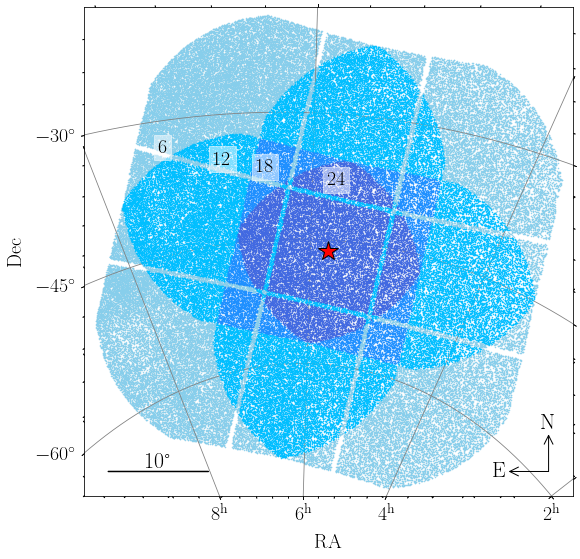

In [98]:
# Plot overall figure
fig = plot.plotPlatoFOV('SPF', 0, 0, fs=20)

# Plot N-CAM visibility
box1 = fig.text(0.250, 0.655, '6',  fontsize=20)
box2 = fig.text(0.335, 0.637, '12', fontsize=20)
box3 = fig.text(0.400, 0.625, '18', fontsize=20)
box4 = fig.text(0.510, 0.605, '24', fontsize=20)

# Plot white boxes below
box1.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box2.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box3.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
box4.set_bbox(dict(facecolor='w', alpha=0.5, edgecolor='w'))
plt.show()

# Save figure
fig.savefig('PlatoFOV.pdf', bbox_inches='tight', dpi=200)

---

## CCD subfields

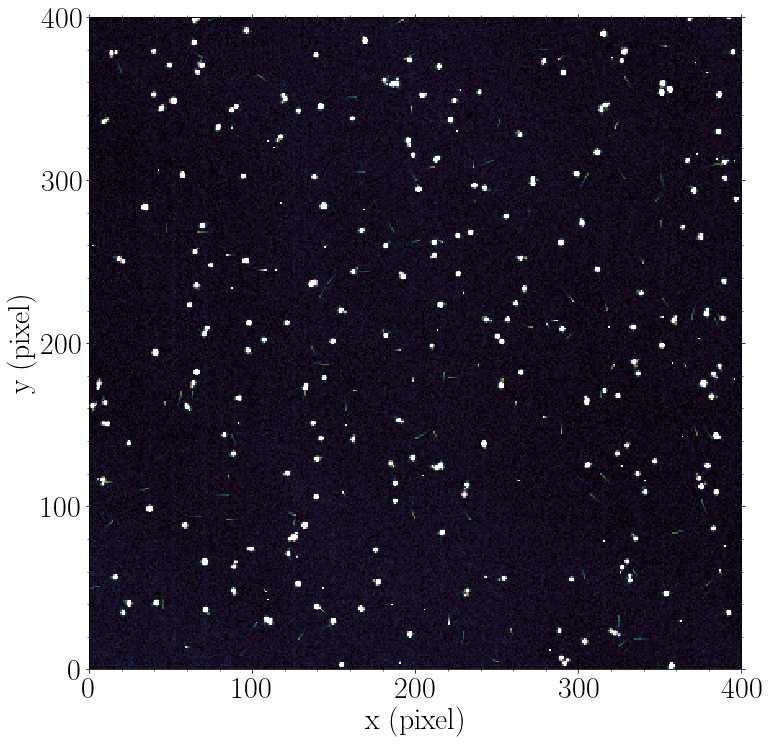

In [29]:
# Initialise PlatoSim (we reuse the inputfile.yaml)
outputFileName = "output_Image"
sim = Simulation(outputFileName, outputDir=outputDir)

# Obs parameters
sim["ObservingParameters/NumExposures"]    = 1

# Sky parameters
sim["Sky/SkyBackground"]         = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
sim["SubField/NumColumns"]      = 400
sim["SubField/NumRows"]         = 400
sim["SubField/ZeroPointColumn"] = 200
sim["SubField/ZeroPointRow"]    = 200

# Run simulation
sim.run(removeOutputFile=True)

# Show image
f0 = SimFile(outputFileName + ".hdf5")
fig = f0.showImage(0, clipPercentile=1, figsize=(12,12), colorMap="cubehelix",
                  showStarPositions=False, showStarIDs=True, useTitle=False,
                  fontSize=30) 

# Save figure
fig.savefig('subfield400x400pix.pdf', bbox_inches='tight', dpi=200)

In [100]:
# Find target from ,catalogue of Image
cat = f0.getStarCatalog()
starID = 13
row = int(cat[6][starID])
col = int(cat[7][starID])
row, col

(-324, -554)

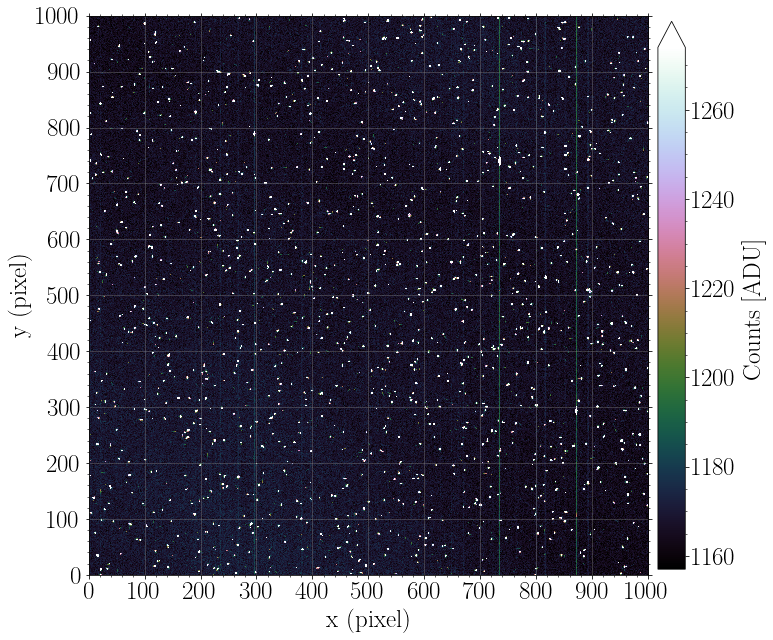

In [101]:
# The above catalogue is wrong! 
# Here we set the subfield further into the CCD and get a correct catalogue..

# Initialise PlatoSim
outputFile = "output_Subfield"
sim = Simulation(outputFile, outputDir=outputDir)

# Obsercation
sim["ObservingParameters/NumExposures"]    = 1

# Sky
sim["Sky/SkyBackground"]         = 300  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
sim["SubField/NumColumns"]      = 1000
sim["SubField/NumRows"]         = 1000
sim["SubField/ZeroPointColumn"] = 0
sim["SubField/ZeroPointRow"]    = 0

# Control HDF5
sim["ControlHDF5Content/WriteStarPositions"] = True

# Run simulation
simFile = sim.run(removeOutputFile=True)

# Show image
f1 = SimFile(outputFile + ".hdf5")
fig = f1.showImage(0, colorMap="cubehelix", clipPercentile=1, figsize=(12,12),
                  showStarPositions=False, showStarIDs=False, useTitle=False,
                  colorBar=True, imgScale="clip", fontSize=25, showGrid=True) 

In [102]:
# Find target from ,catalogue of Image
cat = f1.getStarCatalog()
# Select stars below 10 mag
mag = np.where( (cat[3]>10) * (cat[3]<10.5) )
mags = cat[3][mag]
rows = cat[6][mag]
cols = cat[7][mag]
# Select a star
starID = 1
mag = mags[starID]
row = int(rows[starID])
col = int(cols[starID])
row, col

(-242, -927)

In [103]:
# Initialise PlatoSim
outputFile = "output_Subfield"
sim = Simulation(outputFile, outputDir=outputDir)

# Obsercation
sim["ObservingParameters/NumExposures"]    = 1

# Sky
sim["Sky/SkyBackground"]         = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
sim["SubField/NumColumns"]      = 6
sim["SubField/NumRows"]         = 6
sim["SubField/ZeroPointColumn"] = col - 3
sim["SubField/ZeroPointRow"]    = row - 3

# Control HDF5
sim["ControlHDF5Content/WriteStarPositions"]     = True
sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

# Run simulation
simFile = sim.run(removeOutputFile=True)

# Show image
# f2 = SimFile(outputFile + ".hdf5")
# fig = f2.showImage(0, clipPercentile=20, figsize=(12,12),
#                    showStarPositions="PIC", showStarIDs=False, useTitle=False,
#                    colorBar=True, imgScale="minmax", colorMap="cubehelix",
#                    fontSize=25, showGrid=True, tarMarkerSize=500) 

# # Save figure
# fig.savefig('subfield6x6pix.png', bbox_inches='tight', dpi=200)

# # Print the star catalogue used
# f2.getStarCatalog()


2022-10-12 17:15:59 WARNING Simulation: no information about detected stars to write to HDF5
2022-10-12 17:15:59 WARNING Camera: No star positions to write to HDF5 file.
2022-10-12 17:15:59 WARNING Camera: No point-like ghost positions to write to HDF5 file.



## CTI for EOL


2022-10-13 08:19:58 WARNING Camera: No point-like ghost positions to write to HDF5 file.



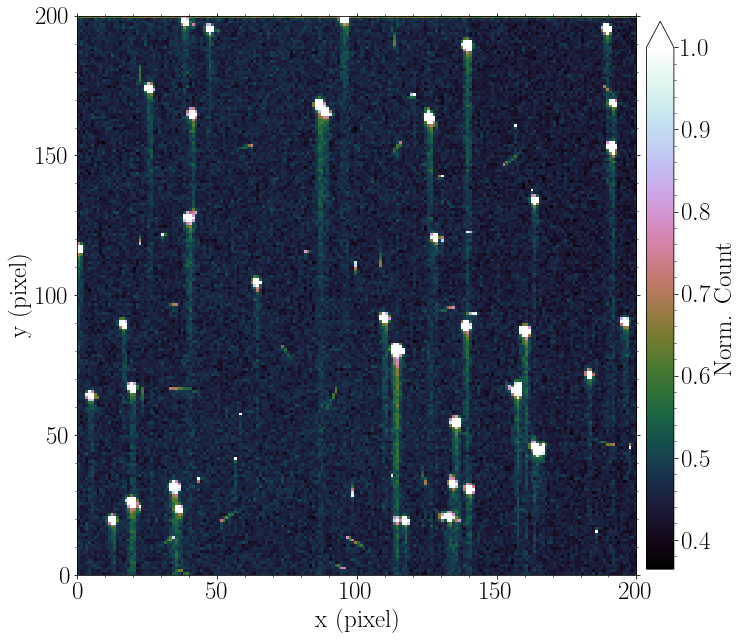

In [34]:
# Initialise PlatoSim
outputFile = "output_CTI"
sim = Simulation(outputFile, outputDir=outputDir)

# Observation
exp = int(6.5 * 365 * 24 * 60 * 60 / 25.)
sim["ObservingParameters/BeginExposureNr"] = exp
sim["ObservingParameters/NumExposures"]    = 1

# Sky
sim["Sky/SkyBackground"]         = -1  # Auto background
sim["Sky/Cosmics/CosmicHitRate"] = 10

# Subfield
sim["SubField/NumColumns"]      = 200
sim["SubField/NumRows"]         = 200
sim["SubField/ZeroPointColumn"] = 2900
sim["SubField/ZeroPointRow"]    = 3100

# Run simulation
simFile = sim.run(removeOutputFile=True)

# Show image
f = SimFile(outputFile + ".hdf5")
fig = f.showImage(exp, colorMap="cubehelix", clipPercentile=0.8, figsize=(12,12),
                  showStarPositions=False, showStarIDs=True, useTitle=False,
                  colorBar=True, imgScale="auto", fontSize=25, showGrid=False, origin="upper") 

# Save figure
fig.savefig('subfieldCTI.pdf', bbox_inches='tight', dpi=200)

---

## Spectral Response curve

In [49]:
grid_no = 1000
path = os.getenv("PLATO_PROJECT_HOME") + "/python/platosim/varsim/data"

# Import PLATO passband
wvl_plato = np.loadtxt(f"{path}/response_plato.txt")[:,0]  # [nm]                                                                                                                
tra_plato = np.loadtxt(f"{path}/response_plato.txt")[:,1]  # Absolute
# Normalize passband
tra_plato /= tra_plato.max()
wvl_int_plato  = np.linspace(wvl_plato[0], wvl_plato[-1], grid_no)                                                                                                                                         
passband_plato = scipy.interpolate.make_interp_spline(wvl_plato, tra_plato, k=3)                                                                                                                                             
tran_int_plato = passband_plato(wvl_int_plato)

# Import TESS passband
wvl_tess = np.loadtxt(f"{path}/response_tess.txt")[:,0]                                                                                                                
tra_tess = np.loadtxt(f"{path}/response_tess.txt")[:,1]                                                                                                              
wvl_int_tess  = np.linspace(wvl_tess[0], wvl_tess[-1], grid_no)                                                                                                                                         
passband_tess = scipy.interpolate.make_interp_spline(wvl_tess, tra_tess, k=3)                                                                                                                                             
tran_int_tess = passband_tess(wvl_int_tess)                                                                                                                                                             
 
# Import Kepler passband                                                                                                                                                                                                                                                                                                                                                                                          
wvl_kepler  = np.loadtxt(f"{path}/response_kepler.txt")[:,0]                                                                                                                  
tran_kepler = np.loadtxt(f"{path}/response_kepler.txt")[:,1]                                                                                                                      
wvl_int_kepler  = np.linspace(wvl_kepler[0], wvl_kepler[-1], grid_no)                                                                                                                                   
passband_kepler = scipy.interpolate.make_interp_spline(wvl_kepler, tran_kepler, k=3)                                                                                                                                      
tran_int_kepler = passband_kepler(wvl_int_kepler) 

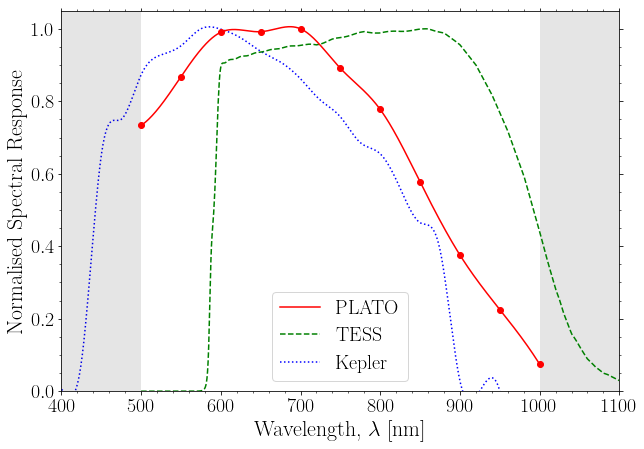

In [50]:
# Create the plot                                                                                                                                                                                       
                                                                                                                                                                                                            
fig, ax = plt.subplots(1, 1, figsize=(10, 7))                                                                                                                                                   
                                                                                                                                                                                                            
# Response functions:
ax.plot(wvl_plato,  tra_plato, 'ro') 
ax.plot(wvl_int_plato,  tran_int_plato,  'r-',  label='PLATO',  zorder=3) 
ax.plot(wvl_int_tess,   tran_int_tess,   'g--', label='TESS',   zorder=2)                                                                                                                                        
ax.plot(wvl_int_kepler, tran_int_kepler, 'b:',  label='Kepler', zorder=1)  
ax.axvspan(400, 500, color='k', alpha=0.1, lw=0)
ax.axvspan(1000, 1100, color='k', alpha=0.1, lw=0)
ax.set_xlabel(r'Wavelength, $\lambda$ [nm]')                                                                                                                                                          
ax.set_ylabel(r'Normalised Spectral Response')                                                                                                                                             
ax.set_xlim(400, 1100)
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

# Save figure
fig.savefig('passbands.pdf', bbox_inches='tight', dpi=200)

---

## Jitter comparison: Prime vs. Red noise

In [35]:
# Load Prime
path = "/lhome/nicholas/Nextcloud/Platoman/Models/Jitter/Prime2020jan"
df = pd.read_csv(f'{path}/01_PLATO_PDR_FPM_02_longrun_APE.csv', delimiter=';', 
                 names=['t', 'x', 'y', 'z'], skiprows=[0,1])

# Let time series start at zero seconds
df['t'] -= df['t'].iloc[0]

# Convert angles from rad -> arcsec
for n in ['x', 'y', 'z']:
    df[n] = df[n] * 206265. 
    
df.head()

,t,x,y,z
0,0.000,0.301147,0.203171,0.056723
1,0.125,0.301147,0.201727,0.060642
2,0.250,0.294959,0.202965,0.066005
3,0.375,0.286708,0.205440,0.072399
4,0.500,0.276395,0.206265,0.077762


In [37]:
# Load simulated PlatoSim red noise jitter
f = h5py.File(f"{outputDir}/redNoiseJitter8Hz.hdf5", "r")
x = f['ACS/Yaw'][:]

In [40]:
# Compute PSD for Prime data
f_prime, psd_prime = periodogram(df["x"], 8, scaling='density')
f_prime   *= 1e6  # [muHz]
psd_prime *= 1e6  # [ppm^2/muHz]

# Compute PSF for PlatoSim red noise
f_red, psd_red = periodogram(x, 8, scaling='density')
f_red   *= 1e6  # [muHz]
psd_red *= 1e6  # [ppm^2/muHz]

# Median filters of 1 min
n = int(60 / 0.125)
psd_prime_med = scipy.ndimage.median_filter(psd_prime, n)
psd_red_med   = scipy.ndimage.median_filter(psd_red,   n)

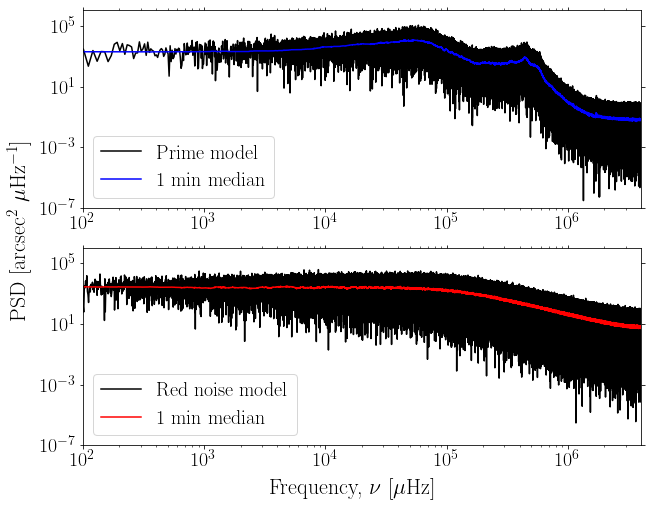

In [42]:
# Creaet plot

fig, ax = plt.subplots(2, 1, figsize=(10,8))

ax[0].plot(f_prime, psd_prime,     "k-", label="Prime model")
ax[0].plot(f_prime, psd_prime_med, "b-", label="1 min median")
ax[1].plot(f_red, psd_red,     "k-", label="Red noise model")
ax[1].plot(f_red, psd_red_med, "r-", label="1 min median")

for i in range(2):
    ax[i].set_xlim(1e2, f_prime.max())
    ax[i].set_ylim(1e-7, 1e6)
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')

fig.text(0.50, 0.04, r"Frequency, $\nu$ [$\mu$Hz]",   ha="center")
fig.text(0.02, 0.50, r"PSD [ppm$^2$ $\mu$Hz$^{-1}$]", va="center", rotation="vertical")
ax[0].legend()
ax[1].legend()
plt.show()

# Save figure
fig.savefig('jitterModelComparison.pdf', bbox_inches='tight', dpi=200)

---

## Zemax PSF

In [327]:
# Initialise PlatoSim
alpha = 5
outputFileName = f"output_HighResPSF_alpha{alpha}"
sim = Simulation(outputFileName, outputDir=outputDir)

# From alpha to focal plane coordinates
focalLength     = sim["Camera/FocalLength/ConstantValue"] * 1000
inPlaneRotation = 45
xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(alpha), focalLength, 
                                                              inPlaneRotation=np.deg2rad(inPlaneRotation))

# From focal plane coordinates to CCD coordinates
pixelSize     = sim["CCD/PixelSize"]
ccdZeroPointX = 0
ccdZeroPointY = 0
CCDangle      = 0
xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, pixelSize, ccdZeroPointX, ccdZeroPointY, CCDangle)

# Observation
sim["ObservingParameters/NumExposures"] = 1

# Subfield
xzero = sim["SubField/ZeroPointRow"]    = int(xCCD)
yzero = sim["SubField/ZeroPointColumn"] = int(yCCD)
xsub  = sim["SubField/NumColumns"]      = 8
ysub  = sim["SubField/NumRows"]         = 8

# PSF
sim["PSF/Model"] = "MappedFromFile"
sim["PSF/MappedFromFile/IncludeChargeDiffusion"] = True

# Control HDF5
sim["ControlHDF5Content/WriteStarPositions"]     = True
sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

# Create star catalogue (path to starcat is automatically by function)
xpos = np.array([int(xsub/2.) + xzero])
ypos = np.array([int(ysub/2.) + yzero])
mag  = np.array([10.0])
ID   = np.array([1])
starcat = outputDir + "/starcat_HighResPSF.txt"
sim.createStarCatalogFileFromPixelCoordinates(xpos, ypos, mag, ID, starcat)

# Run simulation
simFile = sim.run(removeOutputFile=True)


2022-10-24 14:04:49 WARNING Simulation: no information about detected stars to write to HDF5
2022-10-24 14:04:49 WARNING Camera: No star positions to write to HDF5 file.
2022-10-24 14:04:49 WARNING Camera: No point-like ghost positions to write to HDF5 file.



In [328]:
# Initialise PlatoSim
alpha = 18
outputFileName = f"output_HighResPSF_alpha{alpha}"
sim = Simulation(outputFileName, outputDir=outputDir)

# From alpha to focal plane coordinates
focalLength     = sim["Camera/FocalLength/ConstantValue"] * 1000
inPlaneRotation = 45
xFP, yFP = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(np.deg2rad(alpha), focalLength, 
                                                              inPlaneRotation=np.deg2rad(inPlaneRotation))

# From focal plane coordinates to CCD coordinates
pixelSize     = sim["CCD/PixelSize"]
ccdZeroPointX = 0
ccdZeroPointY = 0
CCDangle      = 0
xCCD, yCCD = rf.focalPlaneToPixelCoordinates(xFP, yFP, pixelSize, ccdZeroPointX, ccdZeroPointY, CCDangle)

# Observation
sim["ObservingParameters/NumExposures"] = 1

# Subfield
xzero = sim["SubField/ZeroPointRow"]    = int(xCCD)
yzero = sim["SubField/ZeroPointColumn"] = int(yCCD)
xsub  = sim["SubField/NumColumns"]      = 8
ysub  = sim["SubField/NumRows"]         = 8

# PSF
sim["PSF/Model"] = "MappedFromFile"
sim["PSF/MappedFromFile/IncludeChargeDiffusion"] = True

# Control HDF5
sim["ControlHDF5Content/WriteStarPositions"]     = True
sim["ControlHDF5Content/WriteDiffusedPSF"]       = True
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True

# Create star catalogue (path to starcat is automatically by function)
xpos = np.array([int(xsub/2.) + xzero])
ypos = np.array([int(ysub/2.) + yzero])
mag  = np.array([10.0])
ID   = np.array([1])
starcat = outputDir + "/starcat_HighResPSF.txt"
sim.createStarCatalogFileFromPixelCoordinates(xpos, ypos, mag, ID, starcat)

# Run simulation
simFile = sim.run(removeOutputFile=True)


2022-10-24 14:06:04 WARNING Simulation: no information about detected stars to write to HDF5
2022-10-24 14:06:04 WARNING Camera: No star positions to write to HDF5 file.
2022-10-24 14:06:04 WARNING Camera: No point-like ghost positions to write to HDF5 file.



In [329]:
# Set global parameters for this plot
fs = 25
cm = 'gist_stern'
res = 64 # subpixel/pixel
sub2pix = [0, 64, 128, 192, 255]
ticks =["0", "1", "2", "3", "4"]

In [330]:
f0 = h5py.File(f'{outputDir}/output_HighResPSF_alpha5.hdf5', 'r')
psf0z = np.array(f0["PSF/rotatedPSF"] )[2*res:6*res, 2*res:6*res]  # We only want the inner 4 x 4 pixels
psf0d = np.array(f0["PSF/diffusedPSF"])[2*res:6*res, 2*res:6*res]

f1 = h5py.File(f'{outputDir}/output_HighResPSF_alpha18.hdf5', 'r')
psf1z = np.array(f1["PSF/rotatedPSF"] )[2*res:6*res, 2*res:6*res]  
psf1d = np.array(f1["PSF/diffusedPSF"])[2*res:6*res, 2*res:6*res]

# Combine for plot
psfZemax = [psf0z, psf1z, psf0d, psf1d]

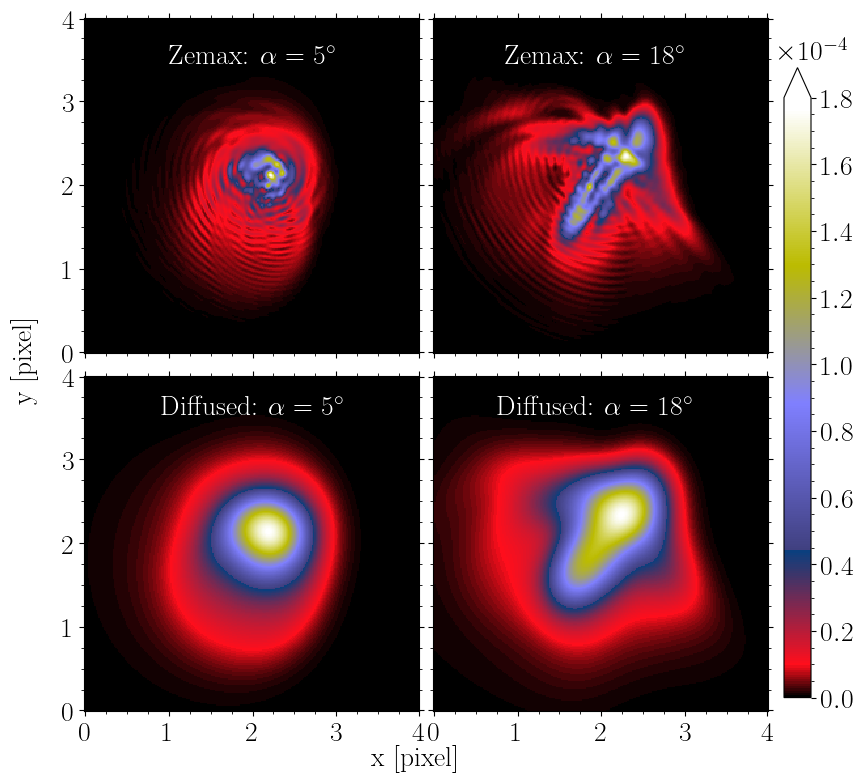

In [334]:
fig, ax = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(9,9))
fig.subplots_adjust(hspace=0.07, wspace=0)

# Create plots
for psf, axes in zip(psfZemax, ax.flat):
    im = axes.imshow(psf, cmap=cm, interpolation='nearest', origin='lower')

    # Settings
    axes.set_xticks(sub2pix)
    axes.set_yticks(sub2pix)
    axes.set_xticklabels(ticks)
    axes.set_yticklabels(ticks)

# Colorbar
cbarax = fig.add_axes([0.91, 0.125, 0.03, 0.7])
cbar = plt.colorbar(im, orientation='vertical', cax=cbarax, extend='max', cmap=cm)                                                                                                                          
cbar.ax.tick_params()
# Colorbar scientific notation
cbar.formatter.set_powerlimits((0, 0))
locs = moveColorbarExponent(x_offs=0.0, y_offs=1.1, dig=1, side='left')

# Set all text
fig.text(0.5, 0.05, 'x [pixel]', ha='center')
fig.text(0.05, 0.5, 'y [pixel]', va='center', rotation='vertical')
fig.text(0.32, 0.83, r'Zemax: $\alpha=5^{\circ}$',     ha='center', color='white')
fig.text(0.70, 0.83, r'Zemax: $\alpha=18^{\circ}$',    ha='center', color='white')
fig.text(0.32, 0.44, r'Diffused: $\alpha=5^{\circ}$',  ha='center', color='white')
fig.text(0.70, 0.44, r'Diffused: $\alpha=18^{\circ}$', ha='center', color='white');

# Save figure
fig.savefig('psfZemax.pdf', bbox_inches='tight', dpi=200)

In [110]:
# # Load Zemax PSF
# f = h5py.File(os.getenv("PLATO_PROJECT_HOME")+'/inputfiles/PSF_Focus_0mu.hdf5', 'r')
# psfZemax0 = np.array(f['298'])[128:384, 128:384]  # 1 pixel is 128 sub-pixels -> We want 4 x 4 pixel
# psfZemax1 = np.array(f['1019'])[128:384, 128:384] # 1 pixel is 128 sub-pixels -> We want 4 x 4 pixel

In [112]:
# fig = plt.figure(figsize=(13,10))

# # Imgshow Zemax PSF
# ax0 = fig.add_subplot(121)
# im0 = ax0.imshow(psfZemax, cmap=cm, interpolation='nearest', origin='lower')
# # Plot colorbar
# cbarax = fig.add_axes([0.49, 0.28, 0.02, 0.42])                                                                                                                                                     
# cbar = plt.colorbar(im0, orientation='vertical', cax=cbarax, extend='max', cmap=cm)                                                                                                                          
# cbar.ax.tick_params(labelsize=fs)
# # Colorbar scientific notation
# cbar.formatter.set_powerlimits((0, 0))
# locs = move_sn_y(x_offs=0.1, y_offs=1.135, side='left')
# # cbar.ax.yaxis.set_offset_position('left')                         
# # cbar.update_ticks()
# # Settings
# ax0.set_xticks(sub2pix)
# ax0.set_yticks(sub2pix)
# ax0.set_xticklabels(ticks)
# ax0.set_yticklabels(ticks)
# ax0.set_xlabel('x (pixel)')
# ax0.set_ylabel('y (pixel)', labelpad=10)

# # 3D plot
# ax1 = fig.add_subplot(122, projection='3d')
# x = np.arange(0, psfZemax.shape[0])
# y = np.arange(0, psfZemax.shape[1])
# X, Y = np.meshgrid(x, y)
# surf = ax1.plot_surface(X, Y, psfZemax, rstride=1, cstride=1, cmap=cm, linewidth=1, antialiased=True)
# ax1.view_init(elev=50, azim=250)
# # Settings
# ax1.locator_params(axis='z', nbins=4)
# ax1.set_xlabel('x (pixel)', labelpad=10)
# ax1.set_ylabel('y (pixel)', labelpad=10)
# ax1.set_xlim(0, max(x))
# ax1.set_ylim(0, max(y))
# ax1.set_xticks(sub2pix)
# ax1.set_yticks(sub2pix)
# ax1.set_xticklabels(ticks)
# ax1.set_yticklabels(ticks)
# ax1.axes.zaxis.set_ticklabels([])

# plt.tight_layout(pad=10)
# plt.show()

# # Save figure
# fig.savefig('psfZemax.pdf', bbox_inches='tight', dpi=200)

---
## Zemax distortion
---

In [311]:
# Load Zemax PSF
f = h5py.File(os.getenv("PLATO_PROJECT_HOME")+'/inputfiles/PSF_Focus_0mu.hdf5', 'r')
coorUnd = f["Coordinates map"]["Undistorted"]
coorDis = f["Coordinates map"]["Distorted"]

# Select data
xund   = coorUnd["x"][:]
yund   = coorUnd["y"][:]
xzemax = coorDis["x"][:]
yzemax = coorDis["y"][:]


In [312]:
# Unfortunately the HDF5 file is a mesh.. so we create a grid and select points from this
x = np.arange(1.3, 85, 4.4)
y = np.arange(1.3, 85, 4.4)
xx, yy = np.meshgrid(x,y)
coords = np.array((xx.ravel(), yy.ravel())).T

# Find indices that matches in undistorted grid point best
dex = []
for i in range(len(coords)):
    r = np.sqrt( (xund-coords[i,0])**2 + (yund-coords[i,1])**2 )
    dex.append(np.argmin(r))

In [313]:
xund   = np.array([xund[i] for i in dex])
yund   = np.array([yund[i] for i in dex])
xzemax = np.array([xzemax[i] for i in dex])
yzemax = np.array([yzemax[i] for i in dex])

In [314]:
# Calculate distortion using the Wang model for analytic PSFs
coeff = [0.32419,  0.0232909,  0.407979, 0.00022463, 0.000217599, 0.000381958, 0.000963902]
focalLength = 247.52
xwang, ywang = rf.undistortedToDistortedFocalPlaneCoordinates(xund, yund, coeff, focalLength)

In [315]:
from matplotlib.patches import Rectangle, Circle

In [316]:
fov_max = np.deg2rad(18.8908)
# rf.gnomonicRadialDistanceFromOpticalAxis(xFP, yFP, focalLength)
fov_max_mm = rf.focalPlaneCoordinatesFromGnomonicRadialDistance(fov_max, focalLength)[0]
fov_max_mm

84.70063682978119

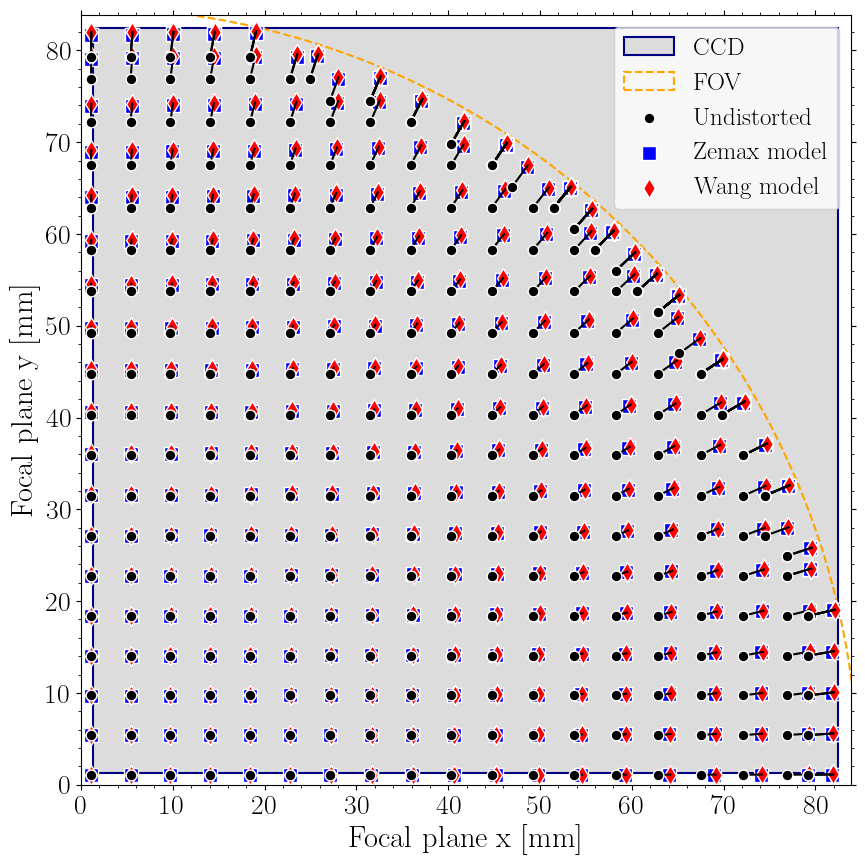

In [326]:
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)

# Plot CCD and FOV footprint
# plt.gca().add_patch(Rectangle((0, 0), 85, 85, facecolor='lightgray', lw=0))
plt.gca().add_patch(Rectangle((1.3, 1.3), 82.48-1.3, 82.48-1.3, edgecolor='navy', facecolor='gainsboro', lw=1.5, label="CCD"))
plt.gca().add_patch(Circle((0, 0), fov_max_mm, color='orange', ls="--", lw=1.5, fill=False, label="FOV"))

# Plot distortions
ax1.scatter(xund,   yund,   s=60,  c="k", edgecolor='w', marker="o", label="Undistorted",      zorder=3)
ax1.scatter(xzemax, yzemax, s=100, c="b", edgecolor='w', marker="s", label="Zemax model", zorder=1)
ax1.scatter(xwang,  ywang,  s=100, c="r", edgecolor='w', marker="d", label="Wang model",  zorder=2)

# Plot attached black line
for i in range(len(xund)):
    ax1.plot([xund[i], xwang[i]], [yund[i], ywang[i]], 'k-', zorder=2)

# ax1.scatter(coords[:,0],  coords[:,1], s=80, c="m", edgecolor='w', marker="^", zorder=3)

# Set labels
ax1.set_xlabel(r"Focal plane x [mm]")
ax1.set_ylabel(r"Focal plane y [mm]")

# Settings
ax1.set_aspect('equal', 'box')
ax1.set_xlim(0, 82.48+1.4)
ax1.set_ylim(0, 82.48+1.4)

ax1.legend(fontsize=18);

# Save figure
fig.savefig('distortion.pdf', bbox_inches='tight', dpi=200)

---
## Spectral transmission
---

In [52]:
# Import PLATO passband
path = "/lhome/nicholas/Nextcloud/Platoman/Models/TOU"
data = np.loadtxt(f"{path}/optical_transmission_ncam.txt")

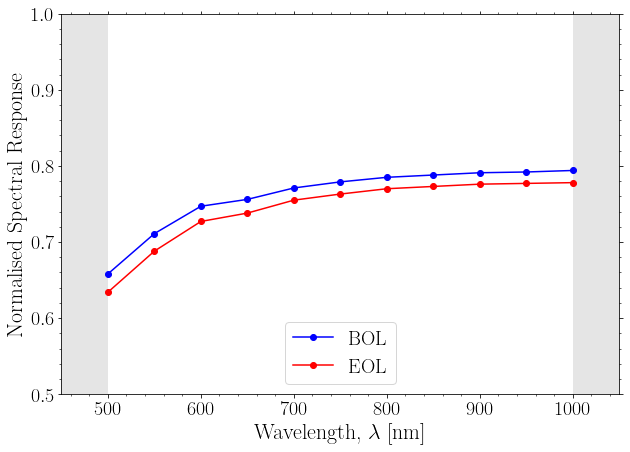

In [56]:
# Create the plot                                                                                                                                                                                       
                                                                                                                                                                                                            
fig, ax = plt.subplots(1, 1, figsize=(10, 7))                                                                                                                                                   
                                                                                                                                                                                                            
# Response functions:
ax.plot(data[:,0],  data[:,1], 'bo-', label='BOL')
ax.plot(data[:,0],  data[:,2], 'ro-', label='EOL') 
# ax.plot(wvl_int_plato,  tran_int_plato,  'r-',  label='PLATO',  zorder=3) 
# ax.plot(wvl_int_tess,   tran_int_tess,   'g--', label='TESS',   zorder=2)                                                                                                                                        
# ax.plot(wvl_int_kepler, tran_int_kepler, 'b:',  label='Kepler', zorder=1)  
ax.axvspan(400, 500, color='k', alpha=0.1, lw=0)
ax.axvspan(1000, 1100, color='k', alpha=0.1, lw=0)
ax.set_xlabel(r'Wavelength, $\lambda$ [nm]')                                                                                                                                                          
ax.set_ylabel(r'Normalised Spectral Response')                                                                                                                                             
ax.set_xlim(450, 1050)
ax.set_ylim(0.5, 1)
ax.legend()
plt.show()

# Save figure
# fig.savefig('passbands.pdf', bbox_inches='tight', dpi=200)